# Inversion on Unimak Island

This is the noteboook that solves the inversion for the Unimak datasets

## Load libraries

In [1]:
%matplotlib widget
import numpy as np
import corner
import matplotlib.pyplot as plt
import matplotlib
import h5py
from vmod import util

# Load GNSS dataset

In this step we load the text file containing the GNSS velocities

grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -165.58673 to -165.5875
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -162.723454 to -162.723333333
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 54.2723509997 to 54.2716666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.0853229994 to 55.0858333333


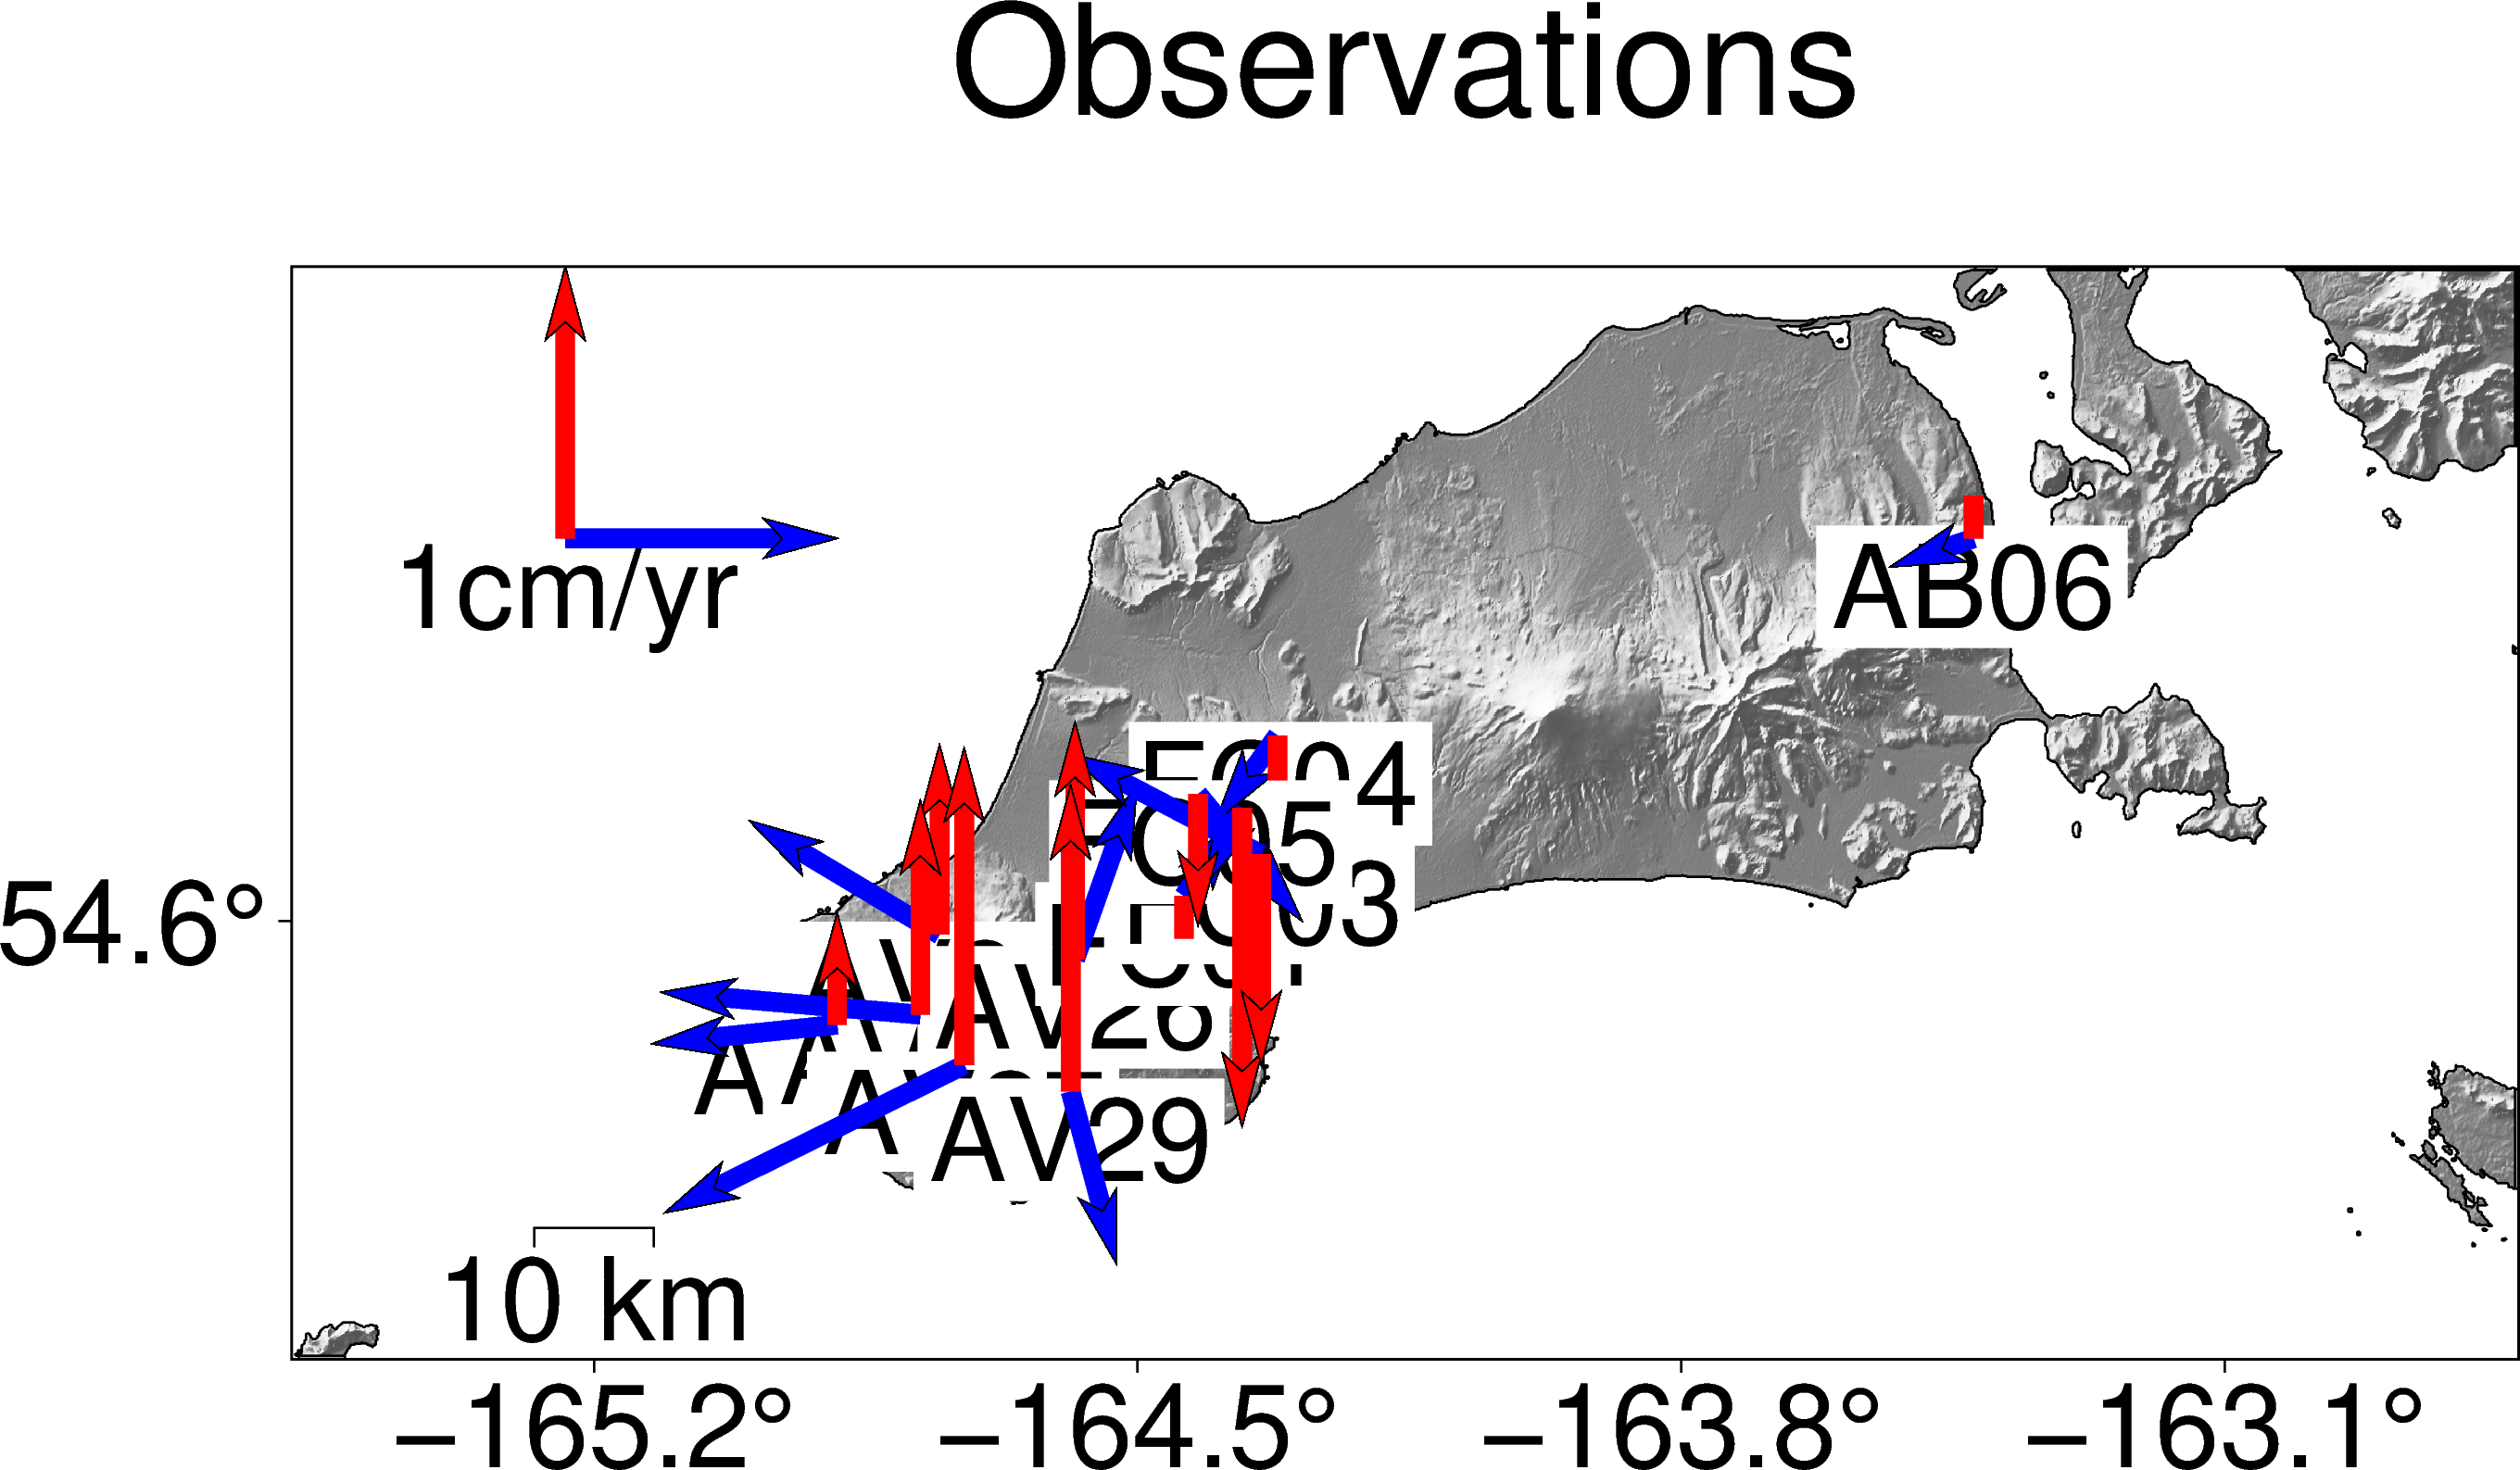

In [2]:
csvfile='examples/gps/unimak_gnss_NOAM.txt'
util.plot_gnss_pygmt(csvfile,title='Observations')

# Import GNSS dataset into a Gnss object

Here we import the csv file with the GNSS velocities and put it into a Gnss object

In [3]:
from vmod.data import Gnss

#Creating observation object in this case 
#an GNSS dataset 
obsg=Gnss()

#Add the names of the stations
#obsg.add_names(names)

#Add the x and y coordinates 
#of the stations
#obsg.add_xs(xs)
#obsg.add_ys(ys)

#Add deformation dataset in east (uxs), 
#north (uys) and vertical (uzs)
#obsg.add_ux(uxs)
#obsg.add_uy(uys)
#obsg.add_uz(uzs)

#Add uncertainties in east (euxs), 
#north (euys) and vertical (euzs)
#obsg.add_errx(euxs)
#obsg.add_erry(euys)
#obsg.add_errz(euzs)

#Import csv into the observation object
obsg.importcsv(csvfile,ori=[-164.5,54.7])
obsg.add_ref('AB06')

In [4]:
#Locations in lat/lon for the sources
#Variable for source locations
points=[(obsg.ori[0],obsg.ori[1])]
#Labels for the points
lpoints=['Origin(x=0, y=0)']

#Coordinates of origin in UTM
x0,y0,z1,z2=util.ll2utm([obsg.ori[0]],[obsg.ori[1]])

In [5]:
uxs,uys,uzs=obsg.get_data(unravel=False)

grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -165.18673 to -165.1875
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -164.0197 to -164.019166667
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 54.3723509997 to 54.3716666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 54.8385004769 to 54.8391666667


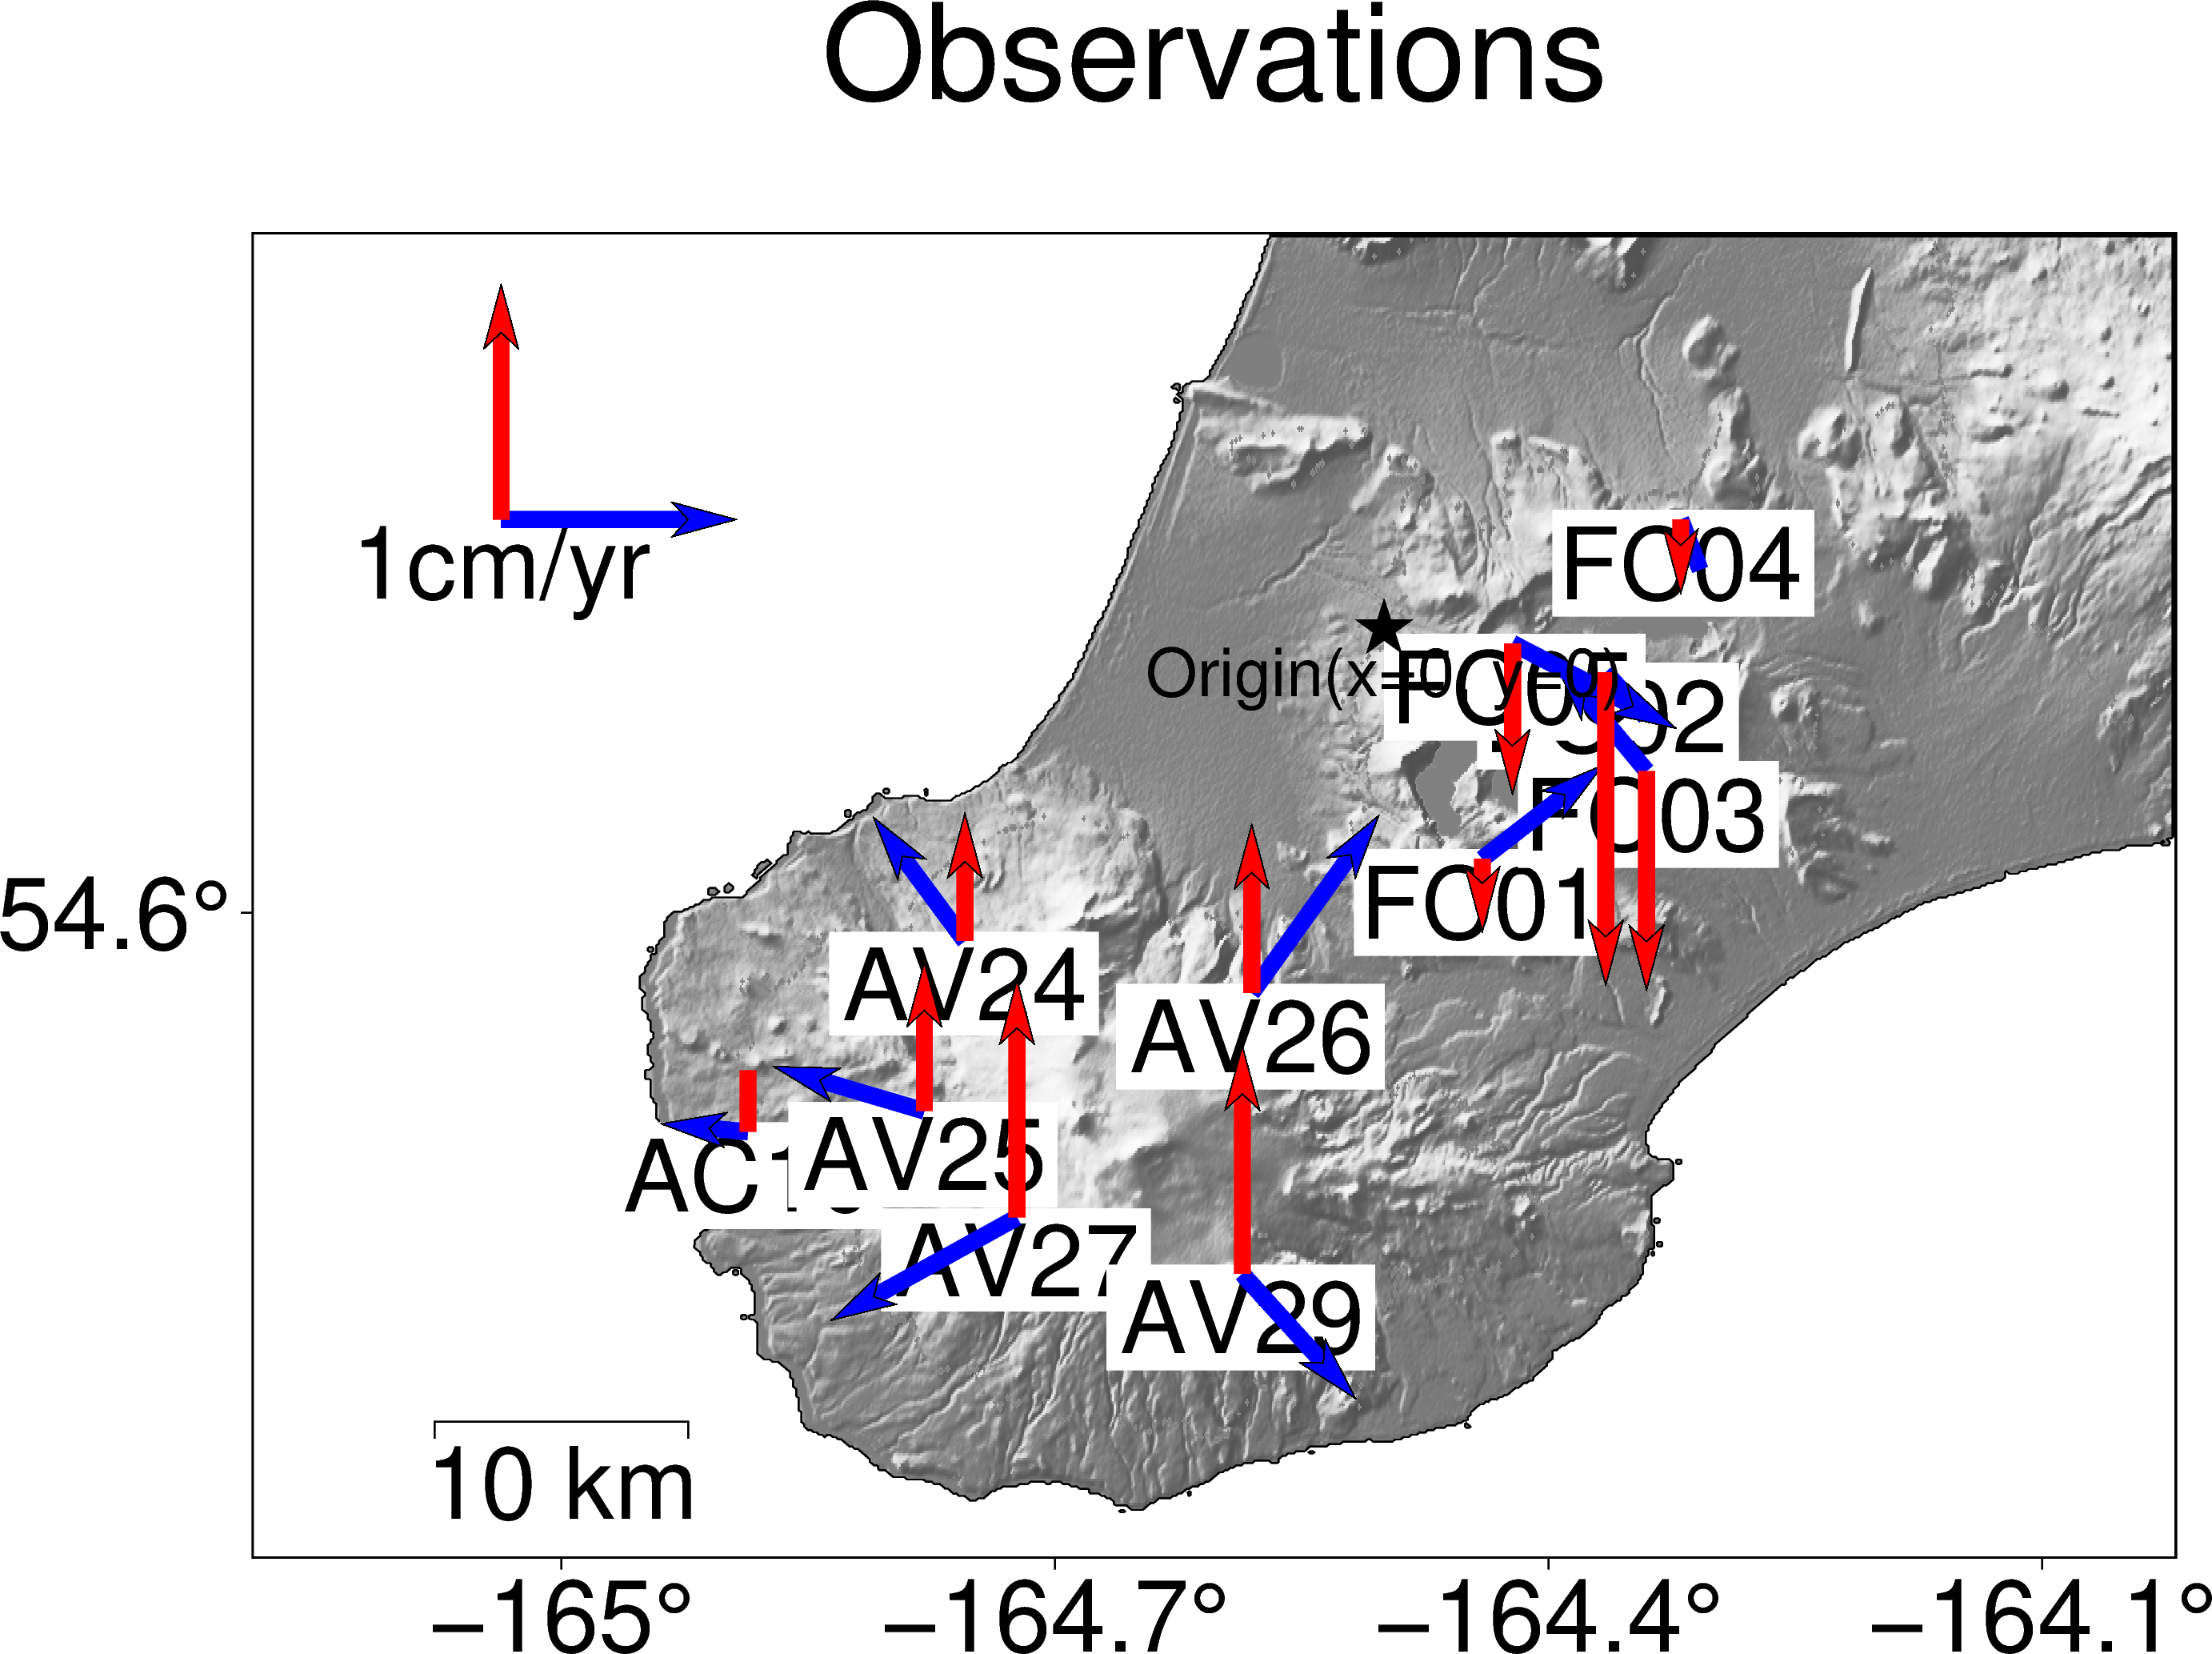

In [6]:
util.plot_gnss_pygmt(csvfile,title='Observations',uxs=uxs,uys=uys,uzs=uzs,ignore=['AB06'],points=points,lpoints=lpoints)

# Model and Inverse objects

Here we create the model and inverse objects to run the inversions. We created some auxiliary objects for plotting purposes.

In [7]:
from vmod.source import Mctigue
from vmod.source import Penny
from vmod.source import Okada
from vmod.source import Yang
from vmod.inverse import Inverse

################# Model objects ##########################################
mctg1 = Mctigue(obsg)
#Bounds for parameters
mctg1.set_bounds(low_bounds = [-30e3,-30e3,1e3,1e2,-1e-2], high_bounds = [30e3,30e3,15e3,5e3,1e-2])

mctg2 = Mctigue(obsg)
#Bounds for parameters
mctg2.set_bounds(low_bounds = [-30e3,-30e3,1e3,1e2,-1e-2], high_bounds = [30e3,30e3,15e3,5e3,1e-2])

################# Inversion object ##########################################

invg=Inverse(obsg)

invg.register_source(mctg1)
invg.register_source(mctg2)

# Non-linear least squares inversion

In this step we run the non-linear least squares inversion and print the results

In [8]:
params=invg.nlsq()

100%|██████████| 64/64 [01:07<00:00,  1.06s/it]


In [9]:
parnames,orders=invg.get_parnames_orders()
for i,parname in enumerate(parnames):
    print(parname,params[i])

xcen0 -9492.223920653534
ycen0 -20412.412109233675
depth0 7519.099937190798
radius0 554.677890354528
dP0 0.009999997884043104
xcen1 8444.597529213288
ycen1 -3575.0726281134152
depth1 4923.274891797903
radius1 399.4341477295247
dP1 -0.007863160194370384


In [10]:
#Coordinates for the center of the sill
lonc1,latc1=util.utm2ll([x0+params[0]],[y0+params[1]],z1,z2)
points.append((lonc1[0][0],latc1[0][0]))
lpoints.append('Sphere1')

#Coordinates for the center of spherical source
lonc2,latc2=util.utm2ll([x0+params[5]],[y0+params[6]],z1,z2)
points.append((lonc2[0][0],latc2[0][0]))
lpoints.append('Sphere2')

## Plotting results from nlsq

Here we use the auxiliary objects to plot the results from the nlsq inversion

grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -165.18673 to -165.1875
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -164.0197 to -164.019166667
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 54.3723509997 to 54.3716666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 54.8385004769 to 54.8391666667


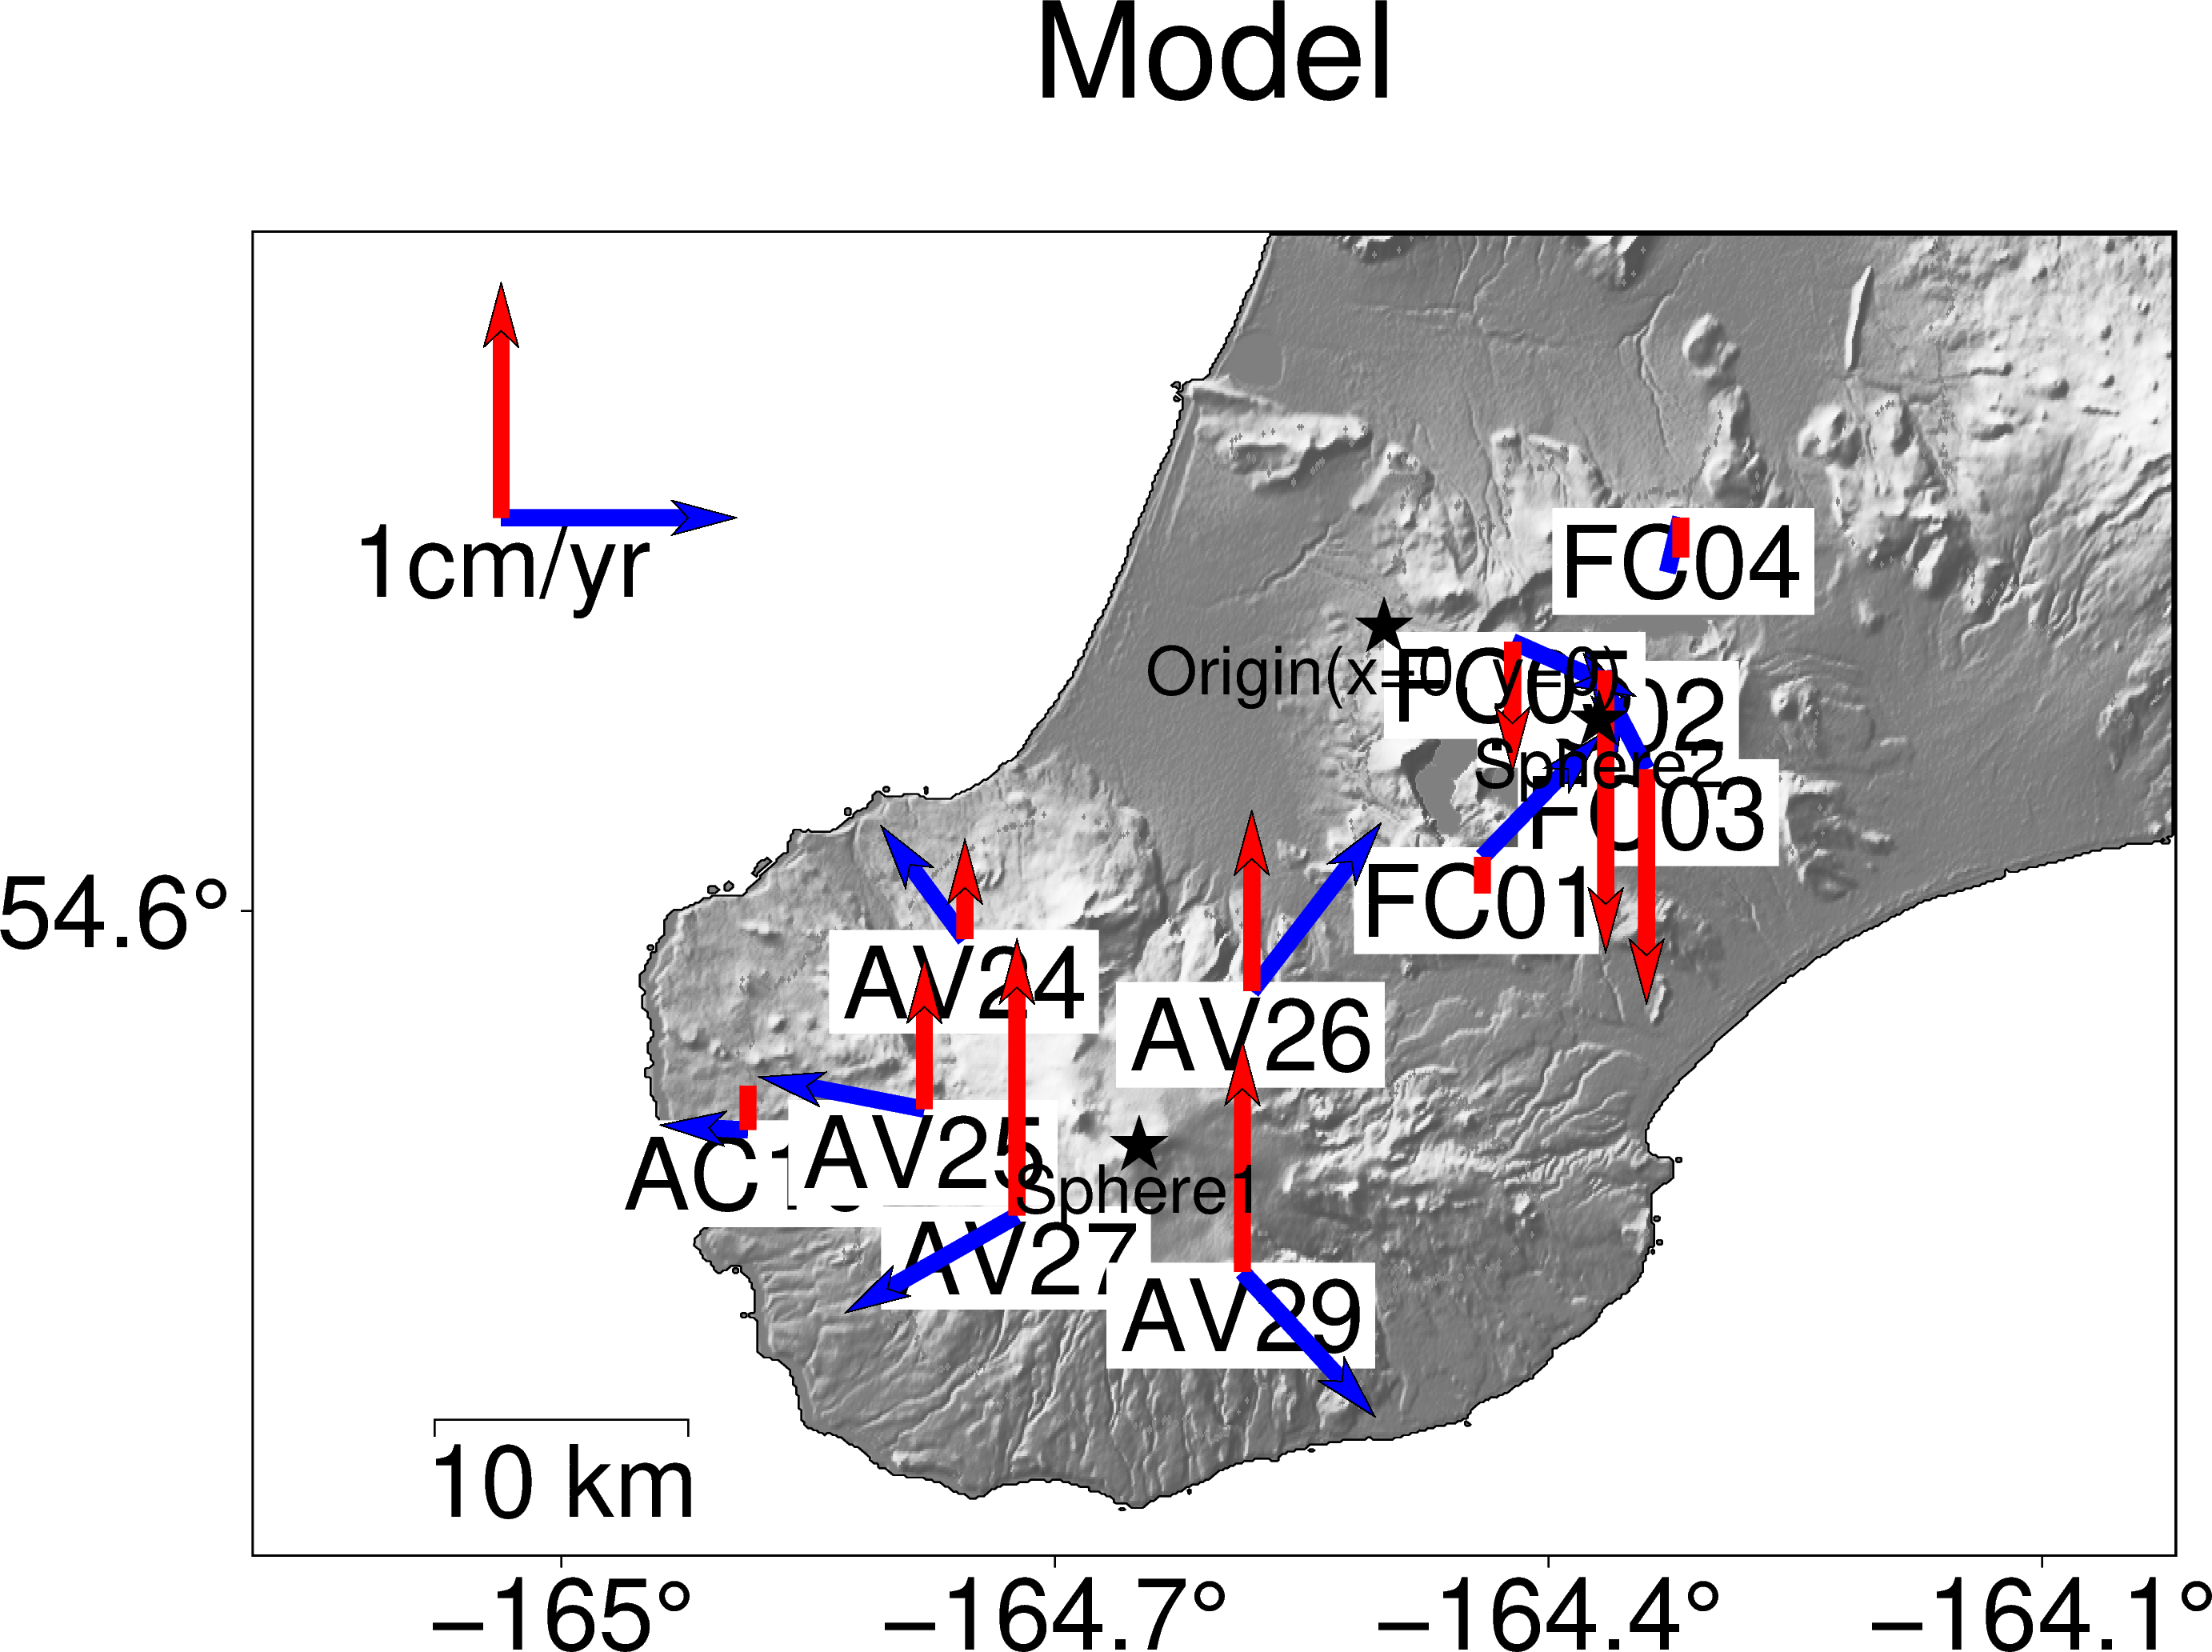

In [11]:
uxsm,uysm,uzsm=invg.forward(params,unravel=False)
util.plot_gnss_pygmt(csvfile,title='Model',uxs=uxsm,uys=uysm,uzs=uzsm,ignore=['AB06'],points=points,lpoints=lpoints)

# Bayesian inversion

When we run the next cell the Bayesian inversion will start

In [ ]:
trace=invg.mcmc_em('unimak_gnss_2mct')

  0%|          | 0/300000 [00:00<?, ?it/s]/home/jovyan/.local/envs/vmod-test/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
 11%|█         | 32426/300000 [15:37<2:06:11, 35.34it/s]

The traces from the Bayesian inversion are stored in a .pkl file

In [12]:
import pickle
with open('unimak_gnss_2mct.pkl','rb') as handle:
    dic=pickle.load(handle)

trace=[dic[key] for key in dic.keys()]

## Plotting results from Bayesian inversion

Here we use the corner library to plot the posterior distributions and we use the auxiliary objects to plot the results

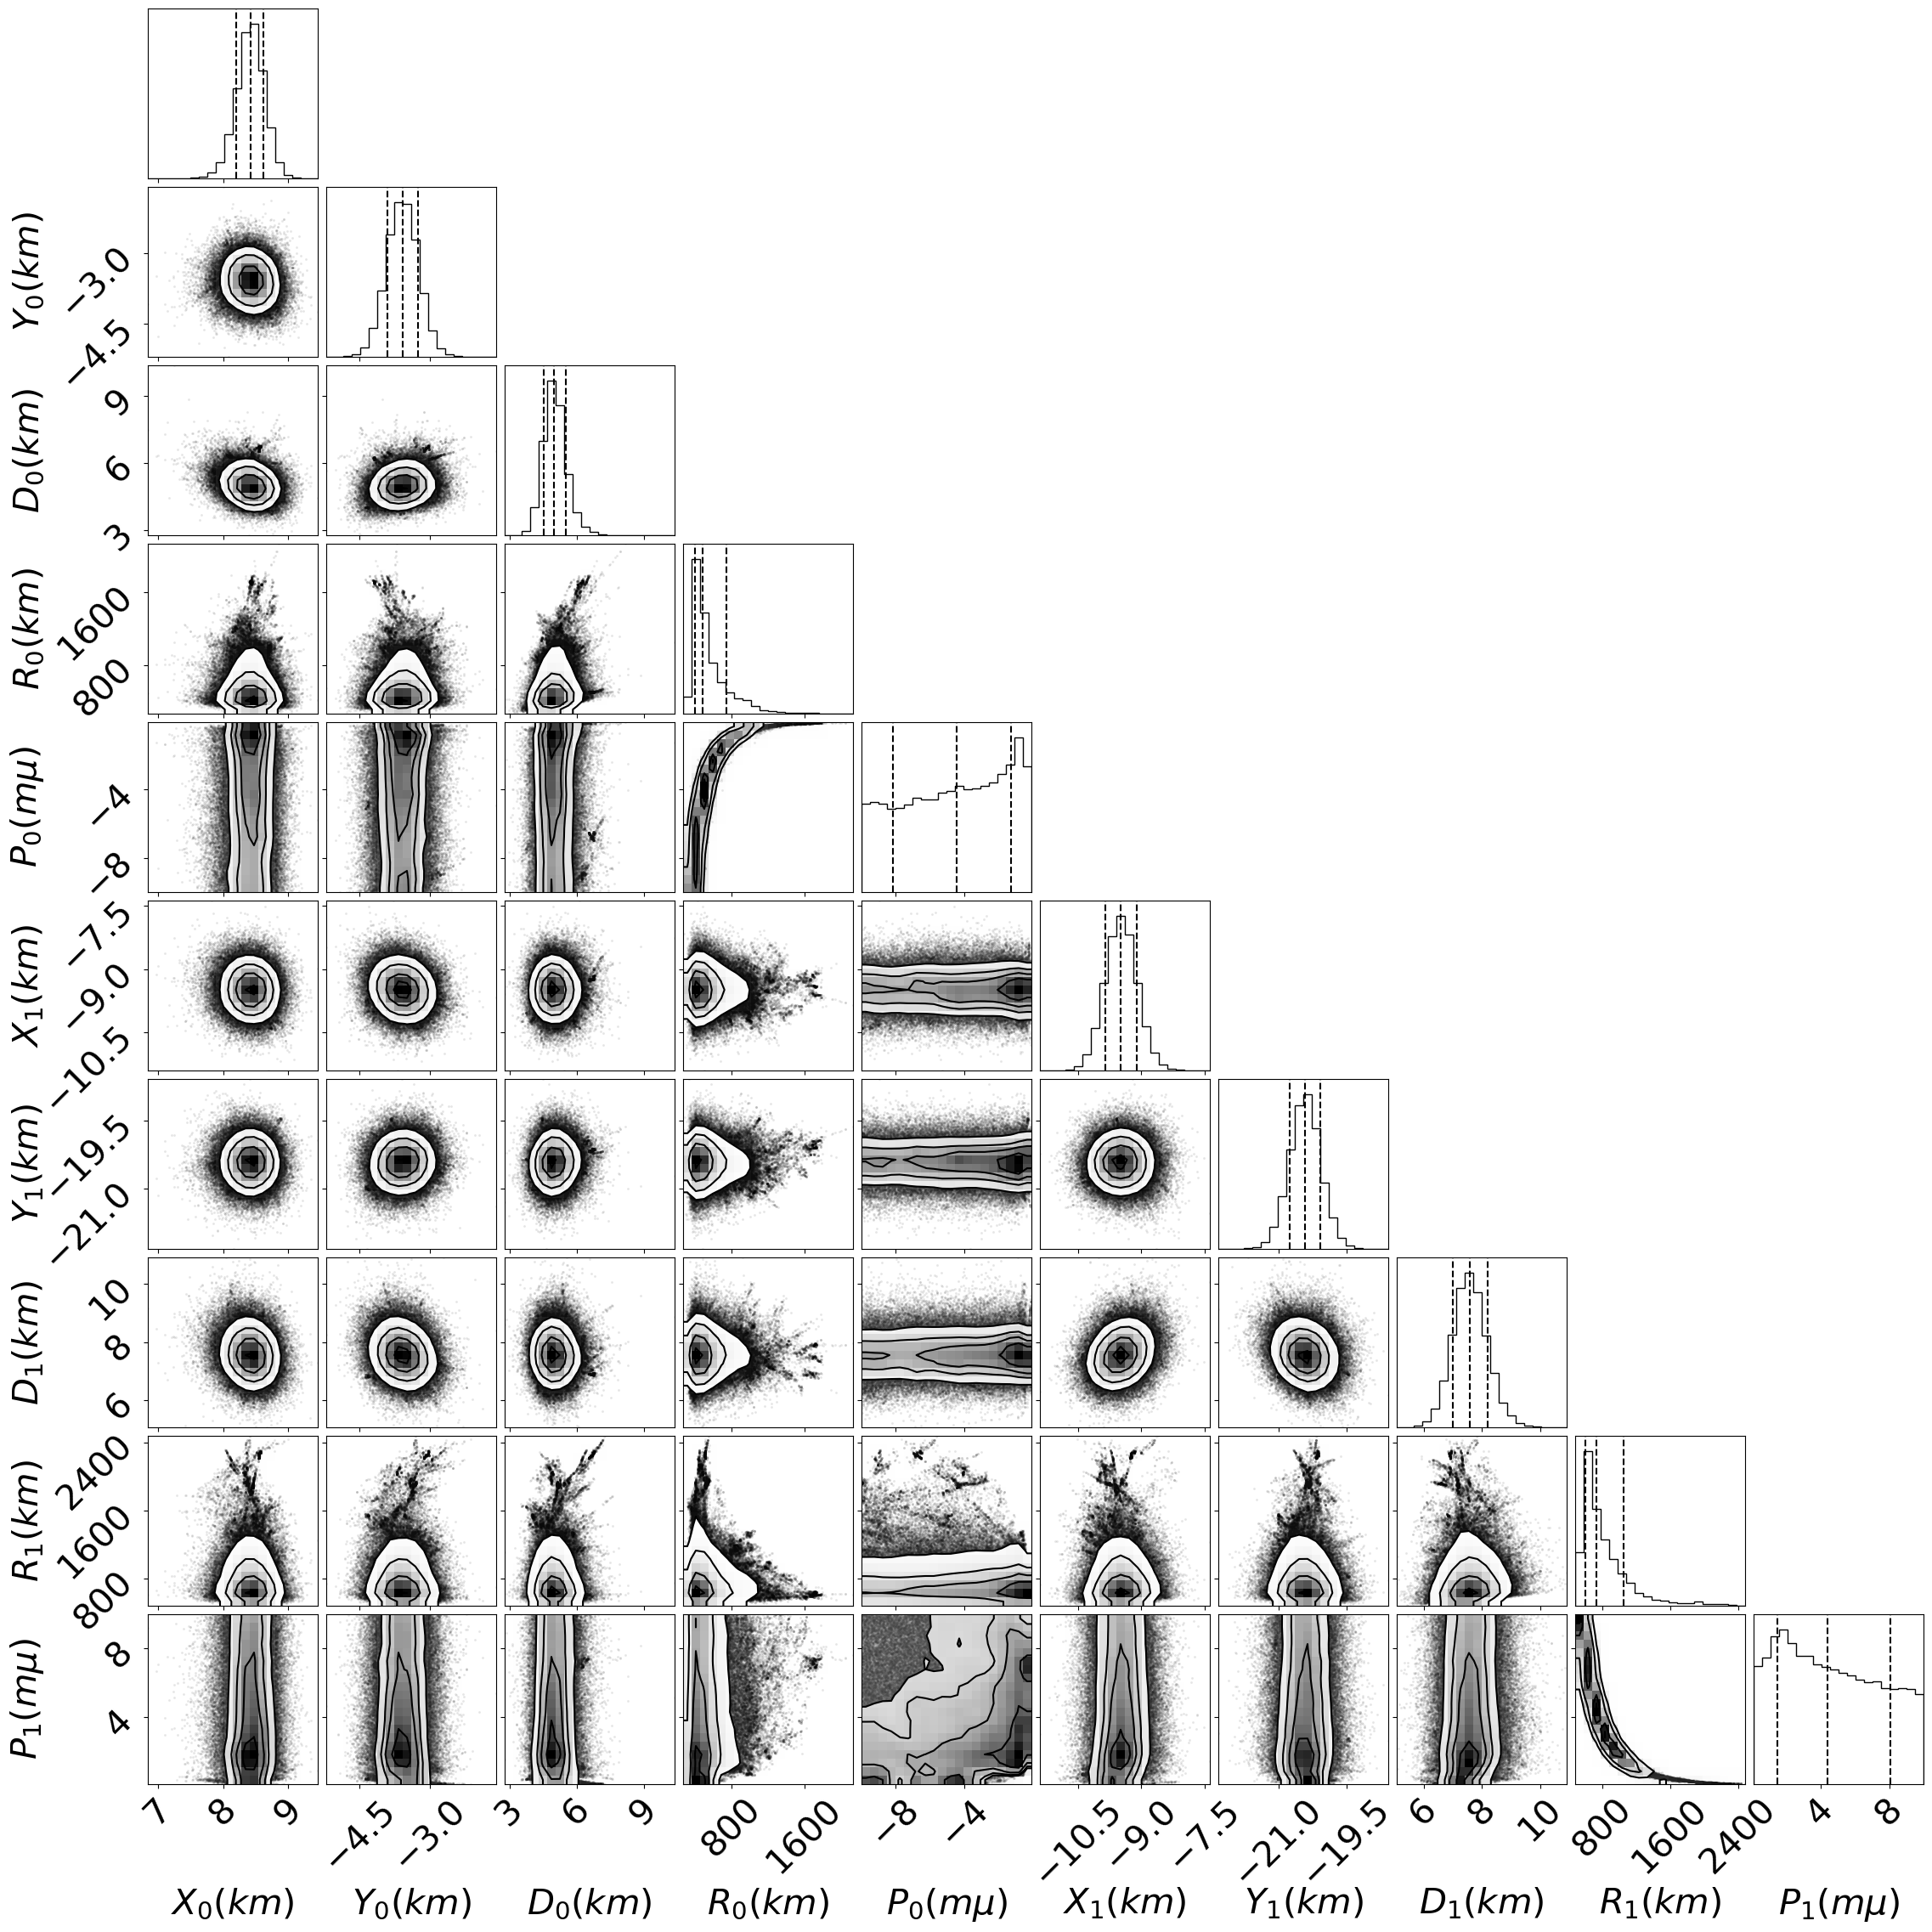

In [13]:
%matplotlib inline
data=[]
labels=[]
parnames,orders=invg.get_parnames_orders()
for i,tr in enumerate(trace):
    data.append(tr[:])
    labels.append(parnames[i])
data=np.vstack(data)

#Copy of the samples in different units for plotting
newdata=np.copy(data)

#Changing location and depth for the first source to km
newdata[0:3,:]=newdata[0:3]/1e3
#Changing pressure for the first source to mmu
newdata[4,:]=newdata[4,:]*1e3
#Changing location and depth for the second source to km
newdata[5:8,:]=newdata[5:8,:]/1e3
#Changing pressure for the second source to mmu
newdata[9,:]=newdata[9,:]*1e3

newlabels=[r'$X_{0} (km)$',r'$Y_{0} (km)$',r'$D_{0}(km)$','$R_{0}(km)$',r'$P_{0} (m\mu)$',r'$X_{1} (km)$',r'$Y_{1} (km)$',r'$D_{1}(km)$','$R_{1}(km)$',r'$P_{1} (m\mu)$']

plt.rcParams.update({'font.size': 30})

figure = corner.corner(newdata.T, labels=newlabels,max_n_ticks=3,smooth=0.7,labelpad=0.3,
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=False, title_kwargs={"fontsize": 30})
plt.savefig('histograms')

In [14]:
bl=np.array([np.percentile(data[i,:],5) for i in range(data.shape[0])])
bh=np.array([np.percentile(data[i,:],95) for i in range(data.shape[0])])

import copy

obsgn=copy.deepcopy(obsg)

mctgn1 = Mctigue(obsgn)
#Bounds for parameters
mctgn1.set_bounds(low_bounds = bl[0:5], high_bounds = bh[0:5])

mctgn2 = Mctigue(obsgn)
#Bounds for parameters
mctgn2.set_bounds(low_bounds = bl[5::], high_bounds = bh[5::])

invb=Inverse(obsgn)
invb.register_source(mctgn1)
invb.register_source(mctgn2)

In [15]:
paramsn=invb.nlsq()

100%|██████████| 64/64 [01:28<00:00,  1.38s/it]


In [16]:
parnames,orders=invb.get_parnames_orders()
for i,parname in enumerate(parnames):
    print(parname,paramsn[i])

xcen0 8444.598595811123
ycen0 -3575.0694273000977
depth0 4923.313074894807
radius0 400.3962340713216
dP0 -0.007806633785071292
xcen1 -9492.224588935896
ycen1 -20412.40497709031
depth1 7519.15303030744
radius1 566.754656864395
dP1 0.00937424116162133


In [17]:
#Variable for uncertainties in the locations
epoints=[(0,0)]

#Coordinates for the center of the sill
lonc1,latc1=util.utm2ll([x0+paramsn[0]],[y0+paramsn[1]],z1,z2)
lonmin1,latmin1=util.utm2ll([x0+np.percentile(data[0,:],5)],[y0+np.percentile(data[1,:],5)],z1,z2)
lonmax1,latmax1=util.utm2ll([x0+np.percentile(data[0,:],95)],[y0+np.percentile(data[1,:],95)],z1,z2)

points[1]=(lonc1[0][0],latc1[0][0])
epoints.append((np.mean(np.abs([lonmin1[0][0]-lonc1[0][0],lonmax1[0][0]-lonc1[0][0]])),np.mean(np.abs([latmin1[0][0]-latc1[0][0],latmax1[0][0]-latc1[0][0]]))))

#Coordinates for the center of spherical source
lonc2,latc2=util.utm2ll([x0+paramsn[5]],[y0+paramsn[6]],z1,z2)
lonmin2,latmin2=util.utm2ll([x0+np.percentile(data[5,:],5)],[y0+np.percentile(data[6,:],5)],z1,z2)
lonmax2,latmax2=util.utm2ll([x0+np.percentile(data[5,:],95)],[y0+np.percentile(data[6,:],95)],z1,z2)

points[2]=(lonc2[0][0],latc2[0][0])
epoints.append((np.mean(np.abs([lonmin2[0][0]-lonc2[0][0],lonmax2[0][0]-lonc2[0][0]])),np.mean(np.abs([latmin2[0][0]-latc2[0][0],latmax2[0][0]-latc2[0][0]]))))

grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -165.18673 to -165.1875
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -164.0197 to -164.019166667
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 54.3723509997 to 54.3716666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 54.8385004769 to 54.8391666667


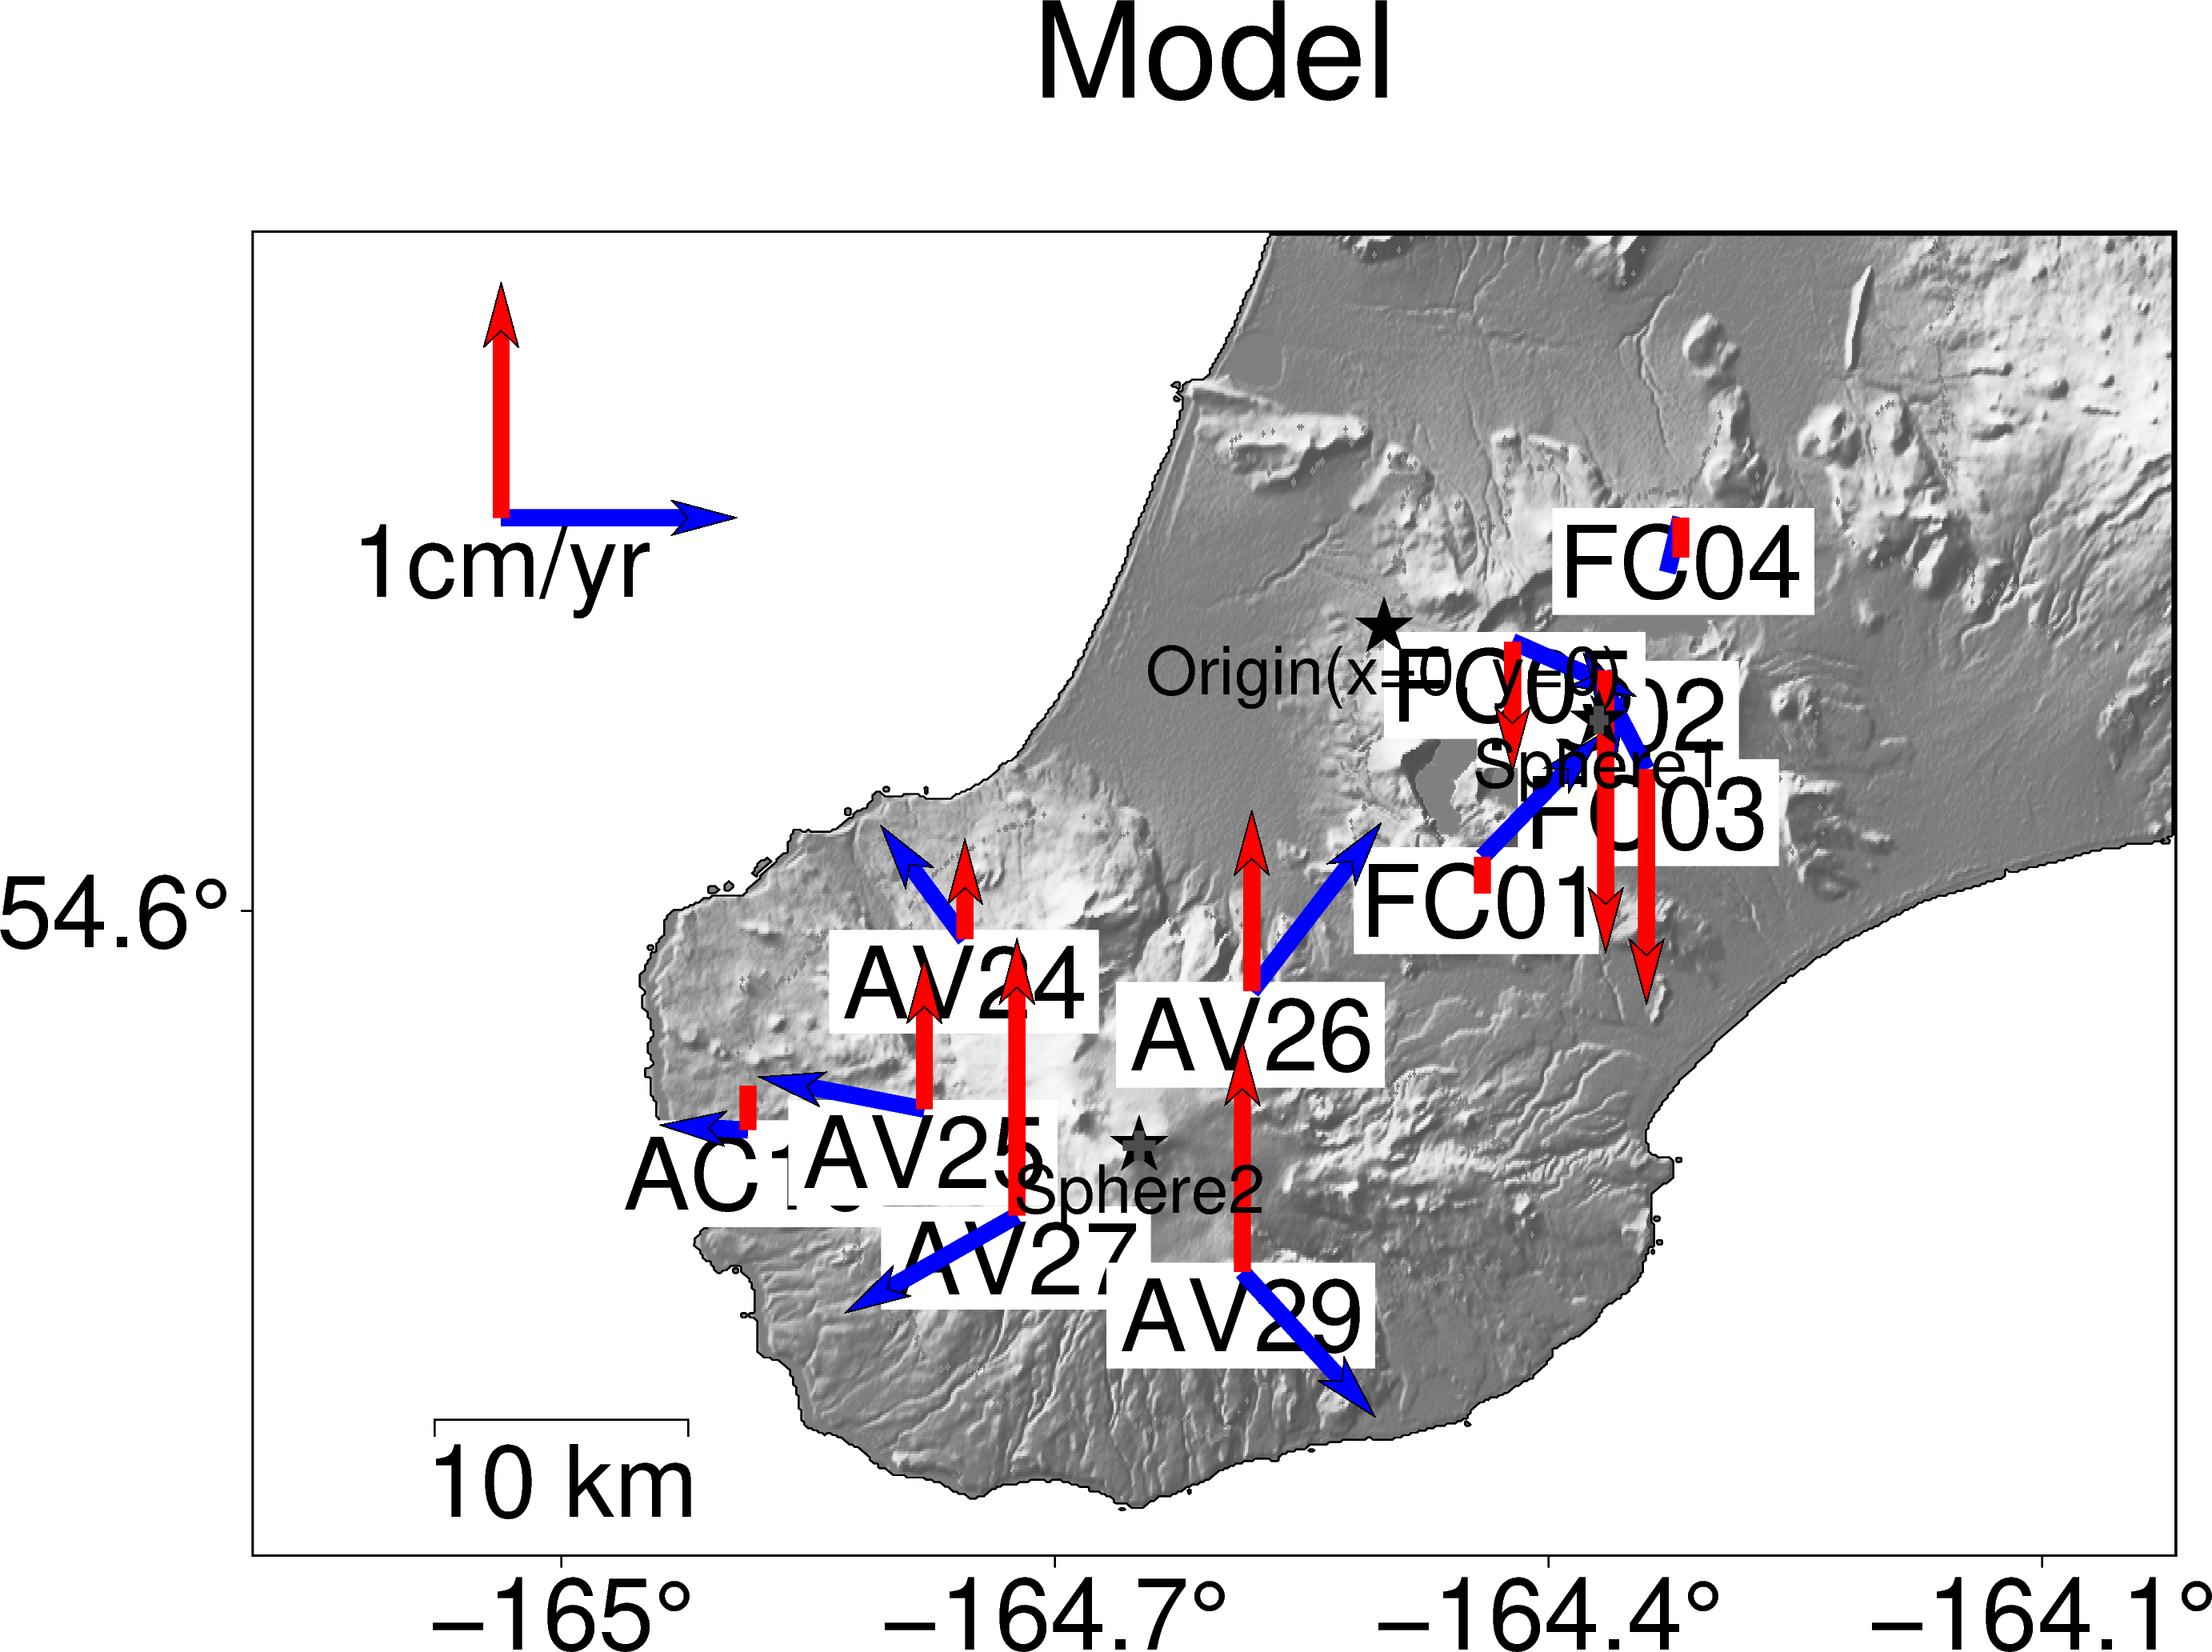

In [18]:
uxsm,uysm,uzsm=invg.forward(params,unravel=False)
util.plot_gnss_pygmt(csvfile,title='Model',uxs=uxsm,uys=uysm,uzs=uzsm,ignore=['AB06'],points=points,lpoints=lpoints,epoints=epoints)

grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -165.18673 to -165.1875
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -164.0197 to -164.019166667
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 54.3723509997 to 54.3716666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 54.8385004769 to 54.8391666667


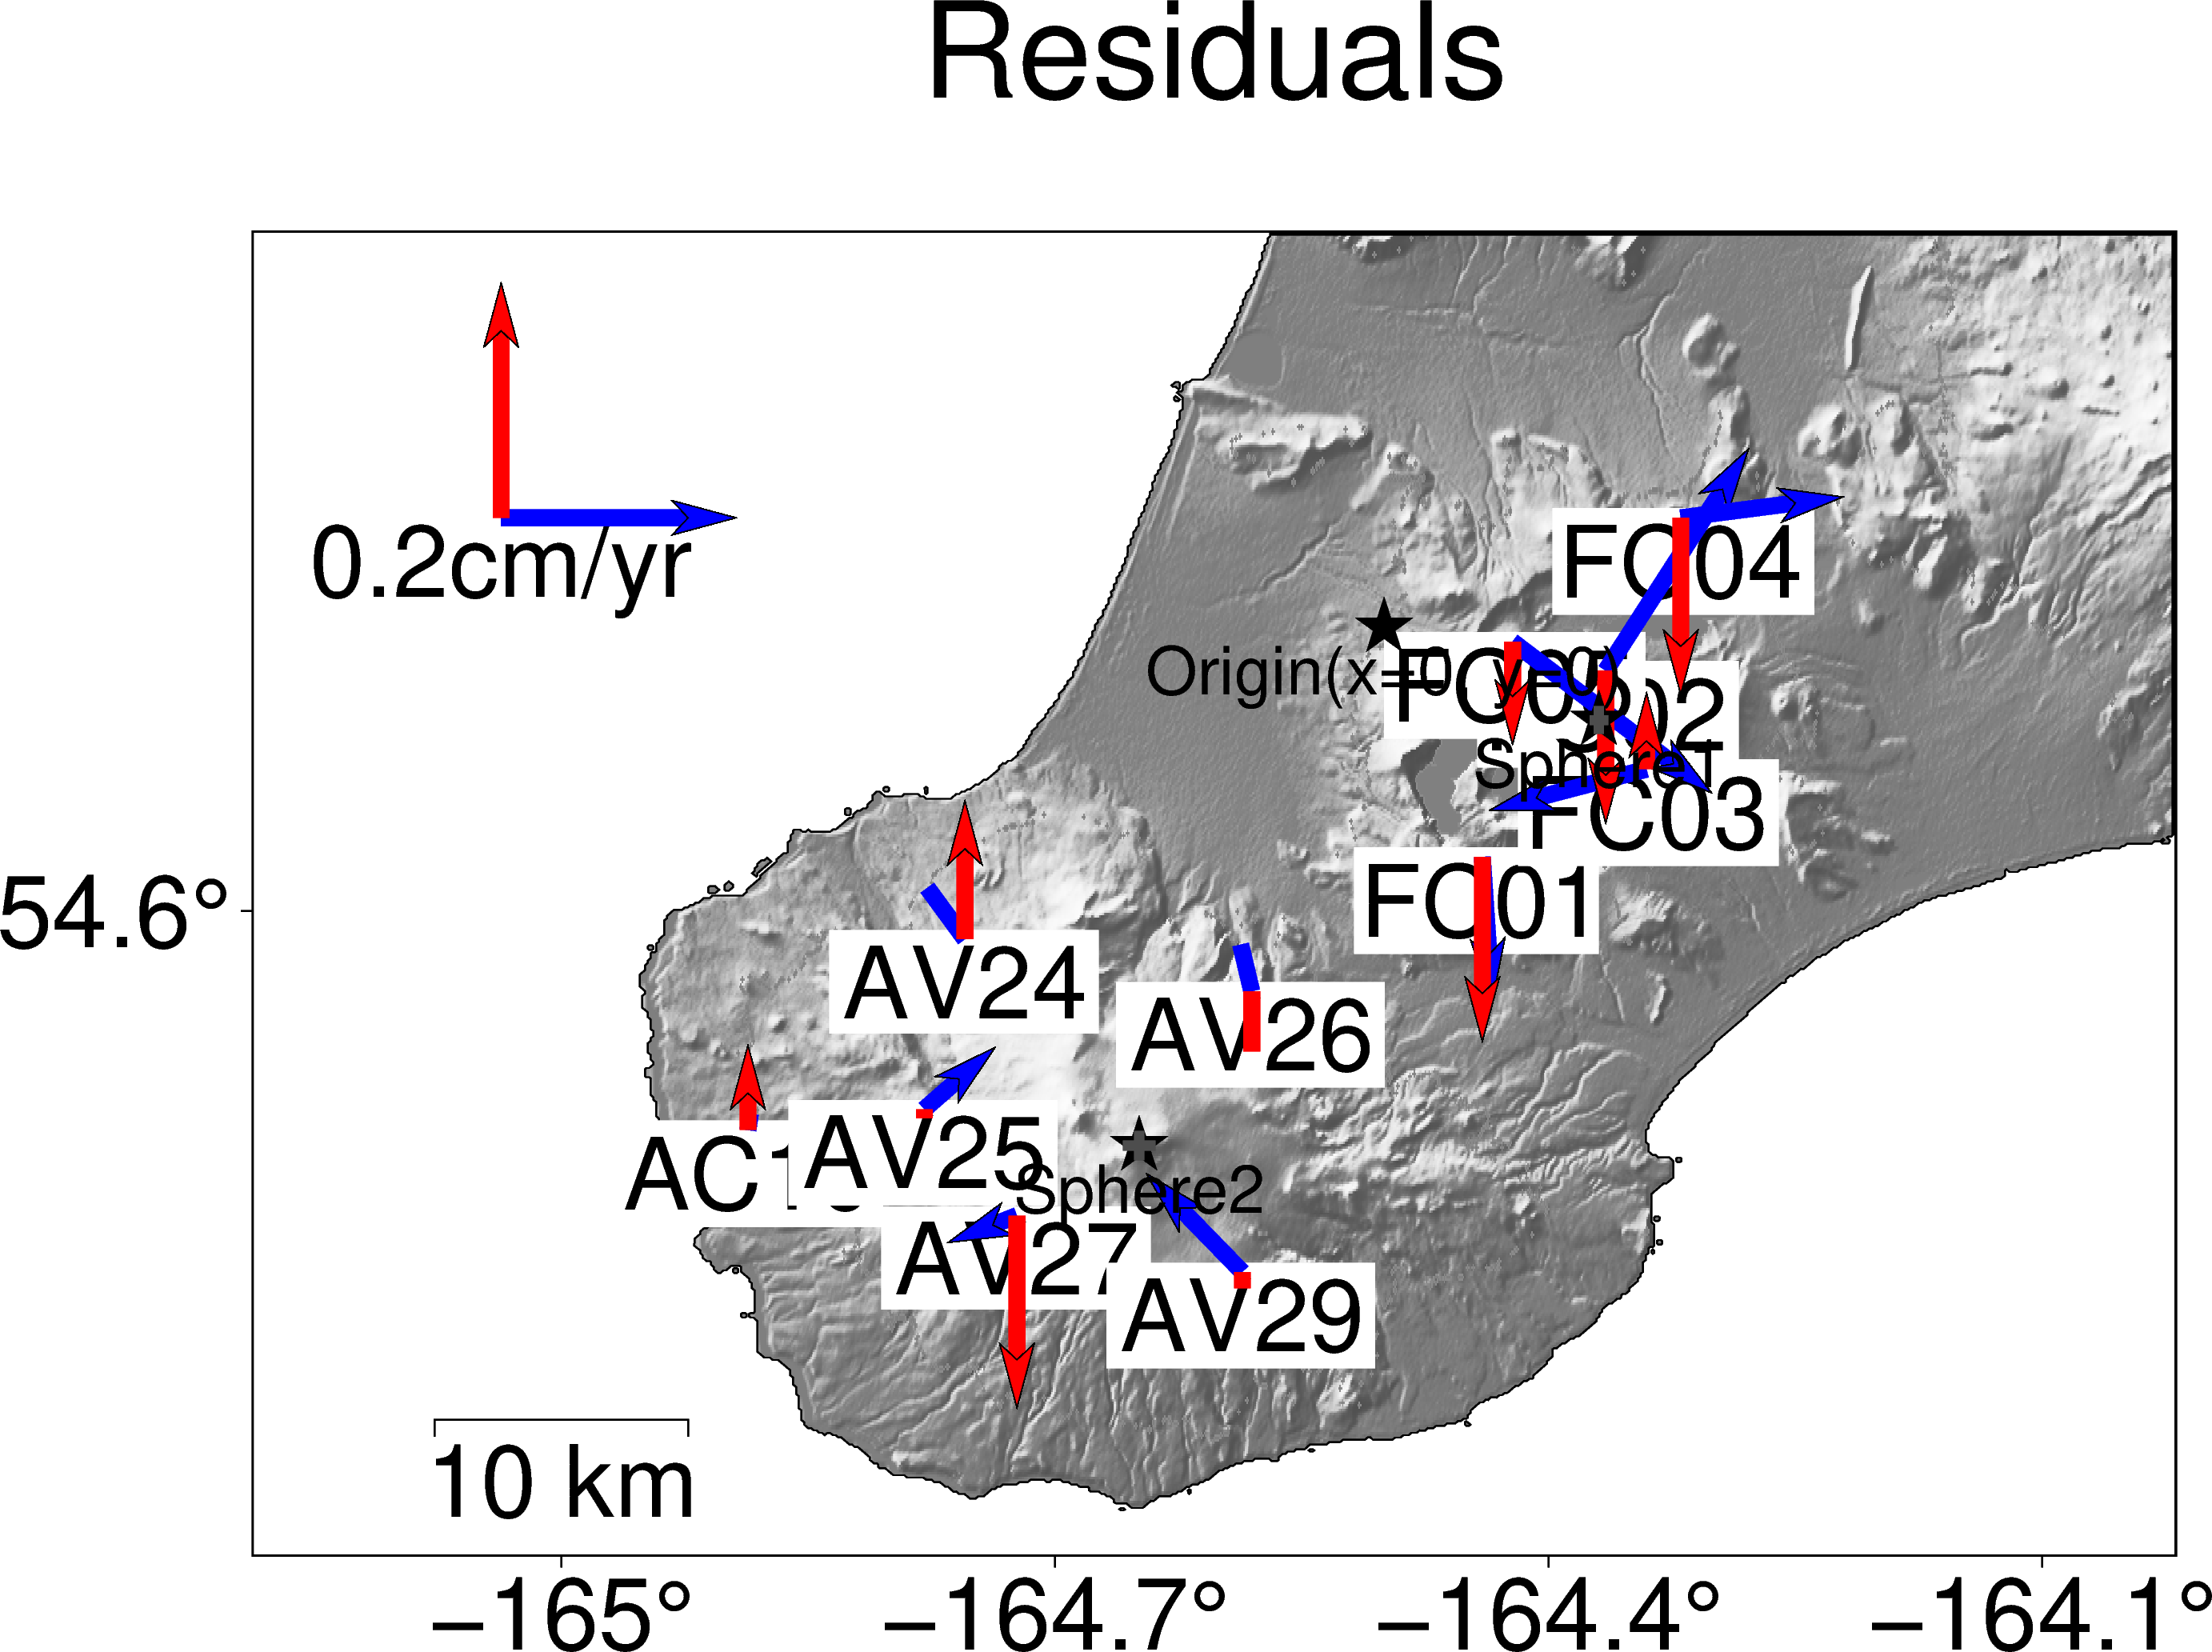

In [19]:
uxs,uys,uzs=obsg.get_data(unravel=False)
util.plot_gnss_pygmt(csvfile,title='Residuals',uxs=uxs-uxsm,uys=uys-uysm,uzs=uzs-uzsm,ignore=['AB06'],arrowscale=0.002,points=points,lpoints=lpoints,epoints=epoints)